In [1]:
import numpy as np
# module load tangermeme

In [3]:
with open('/mnt/lab_data2/anusri/enformer_interpret/enformer.npy', 'rb') as f:
    enformer_attr = np.load(f)

with open('/mnt/lab_data2/anusri/enformer_interpret/chrombpnet_dnase.npy', 'rb') as f:
    dnase_attr = np.load(f)

with open('/mnt/lab_data2/anusri/enformer_interpret/chrombpnet_atac.npy', 'rb') as f:
    atac_attr = np.load(f)

In [4]:
import pyfaidx
from tangermeme.utils import one_hot_encode
from tangermeme.utils import random_one_hot
from tangermeme.ersatz import substitute

pos0=5271188
chrm = 'chr11'
SEQLEN=2114

genome = pyfaidx.Fasta("/mnt/lab_data2/anusri/chrombpnet/reference/male.hg19.fa")
seq = genome[chrm][pos0-SEQLEN//2:pos0+SEQLEN//2].seq.upper()
X = one_hot_encode(seq).unsqueeze(0).float().numpy()
X.shape

with open('chrombpnet_dnase_profile.npy', 'rb') as f:
    profile_dnase_attr = np.load(f)

with open('chrombpnet_atac_profile.npy', 'rb') as f:
    profile_atac_attr = np.load(f)

ModuleNotFoundError: No module named 'tangermeme'

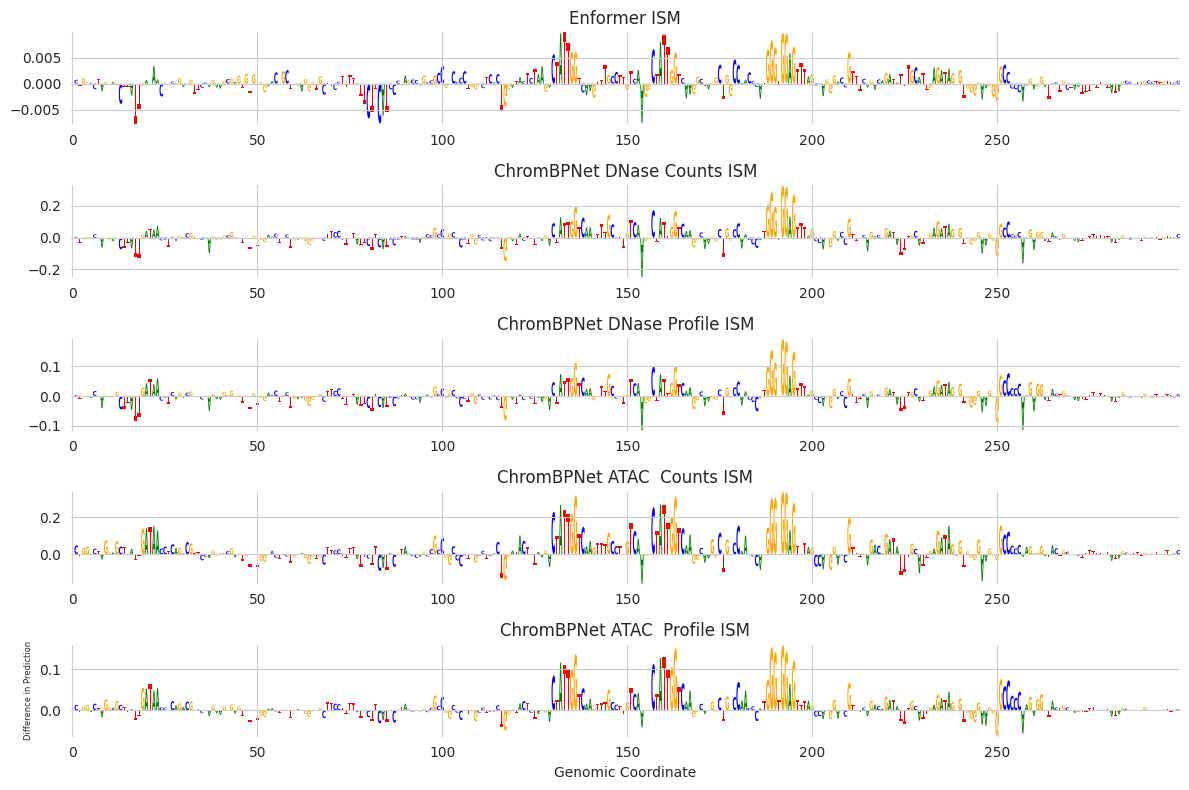

In [12]:
import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('whitegrid')
from tangermeme.plot import plot_logo

fig, axs = plt.subplots(nrows=5, ncols=1, figsize=(12, 8)) # Creates 3 vertically stacked subplots

plot_logo((enformer_attr * X[:, :, SEQLEN//2-150:SEQLEN//2+150])[0], ax=axs[0])
plot_logo((dnase_attr * X[:, :, SEQLEN//2-150:SEQLEN//2+150])[0], ax=axs[1])
plot_logo((profile_dnase_attr * X[:, :, SEQLEN//2-150:SEQLEN//2+150])[0], ax=axs[2])
plot_logo((atac_attr * X[:, :, SEQLEN//2-150:SEQLEN//2+150])[0], ax=axs[3])
plot_logo((profile_atac_attr * X[:, :, SEQLEN//2-150:SEQLEN//2+150])[0], ax=axs[4])

axs[0].set_title("Enformer ISM")
axs[1].set_title("ChromBPNet DNase Counts ISM")
axs[2].set_title("ChromBPNet DNase Profile ISM")
axs[3].set_title("ChromBPNet ATAC  Counts ISM")
axs[4].set_title("ChromBPNet ATAC  Profile ISM")

axs[4].set_xlabel("Genomic Coordinate")
axs[4].set_ylabel("Difference in Prediction", fontsize=6)
# plt.title("Ref Allele")
# axs[0].set_ylim((0,max_v1))
# axs[1].set_ylim((0,max_v1))
plt.tight_layout()


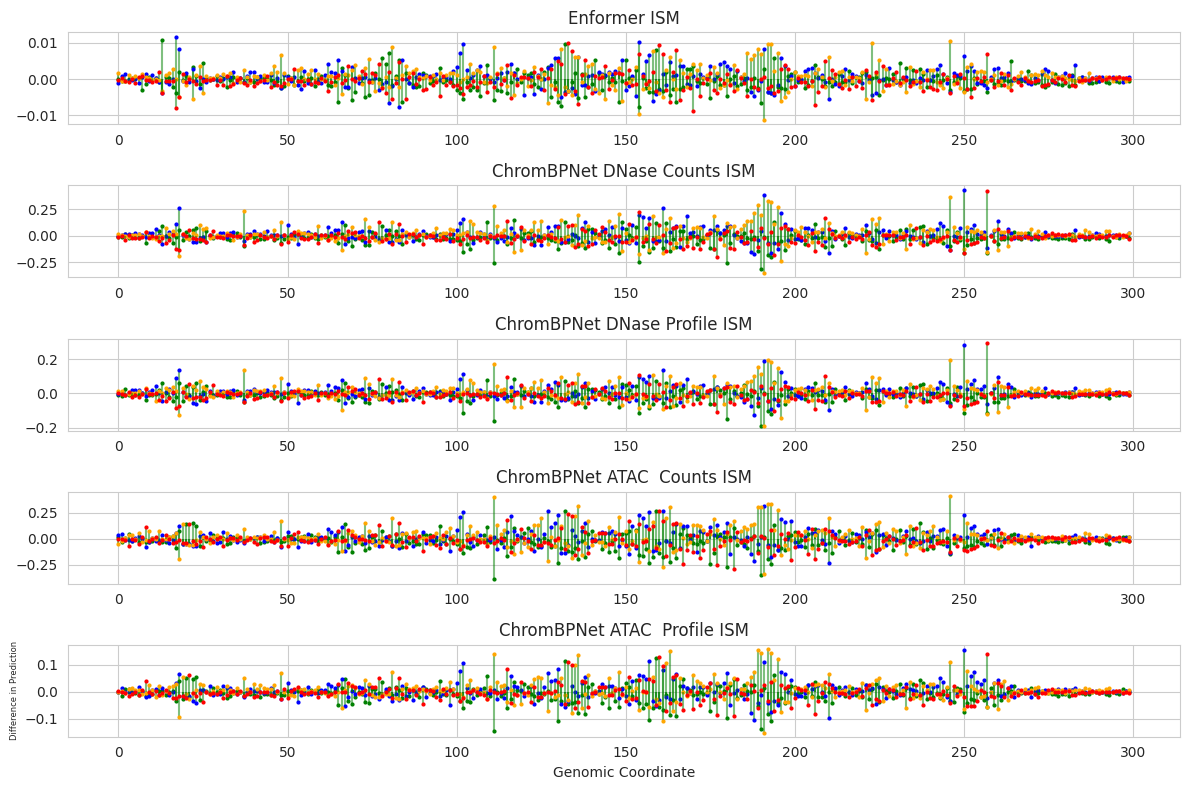

In [14]:
def create_custom_stem_plots(X, ax, size=2, alpha_value=0.5):
    """
    Creates stemplots with custom colors and settings.

    Parameters:
    X : numpy array
        Data array for the stemplots.
    ax : matplotlib axis
        Axis on which to plot the stemplots.
    size : int, optional
        Size of the markers (bulbs). Default is 2.
    alpha_value : float, optional
        Transparency value for the green stacks. Default is 0.5.
    """
    green_with_alpha = [0, 0.5, 0, alpha_value]

    c = [[0, 0.5, 0], [0, 0, 1], [1, 0.65, 0], [1, 0, 0]]

    for i in range(4):
        (markerline, stemlines, baseline) = ax.stem(X[0, i, :], linefmt='g-', markerfmt='o', basefmt=' ')
        markerline.set_color(c[i])  # set the color of the bulbs
        markerline.set_markersize(size)  # reduce bulb size
        stemlines.set_color(green_with_alpha)

# Example usage
fig, axs = plt.subplots(nrows=5, ncols=1, figsize=(12, 8)) # Creates 3 vertically stacked subplots

create_custom_stem_plots(enformer_attr, axs[0], size=2, alpha_value=0.5)
create_custom_stem_plots(dnase_attr, axs[1], size=2, alpha_value=0.5)
create_custom_stem_plots(profile_dnase_attr, axs[2], size=2, alpha_value=0.5)
create_custom_stem_plots(atac_attr, axs[3], size=2, alpha_value=0.5)
create_custom_stem_plots(profile_atac_attr, axs[4], size=2, alpha_value=0.5)

axs[0].set_title("Enformer ISM")
axs[1].set_title("ChromBPNet DNase Counts ISM")
axs[2].set_title("ChromBPNet DNase Profile ISM")
axs[3].set_title("ChromBPNet ATAC  Counts ISM")
axs[4].set_title("ChromBPNet ATAC  Profile ISM")

axs[4].set_xlabel("Genomic Coordinate")
axs[4].set_ylabel("Difference in Prediction", fontsize=6)
# plt.title("Ref Allele")
# axs[0].set_ylim((0,max_v1))
# axs[1].set_ylim((0,max_v1))
plt.tight_layout()

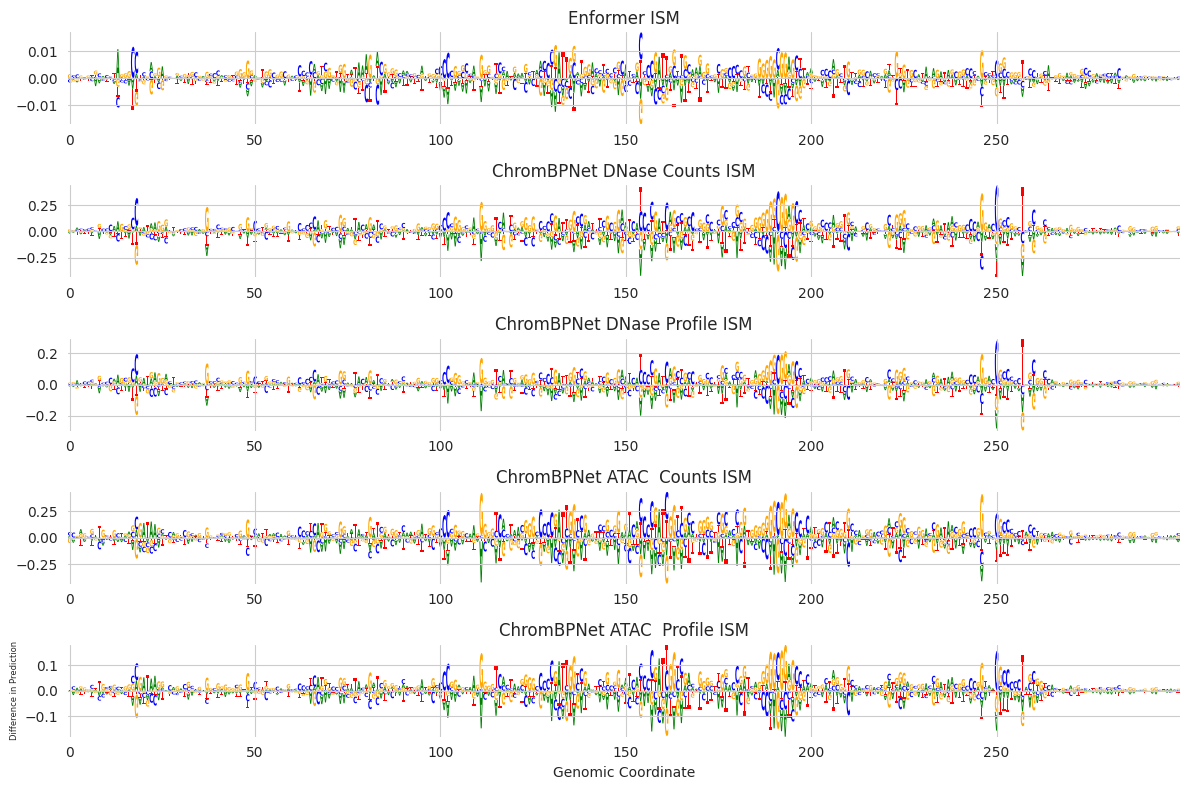

In [34]:
import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('whitegrid')
from tangermeme.plot import plot_logo

fig, axs = plt.subplots(nrows=5, ncols=1, figsize=(12, 8)) # Creates 3 vertically stacked subplots

plot_logo((enformer_attr)[0], ax=axs[0])
plot_logo((dnase_attr)[0], ax=axs[1])
plot_logo((profile_dnase_attr)[0], ax=axs[2])
plot_logo((atac_attr)[0], ax=axs[3])
plot_logo((profile_atac_attr)[0], ax=axs[4])

axs[0].set_title("Enformer ISM")
axs[1].set_title("ChromBPNet DNase Counts ISM")
axs[2].set_title("ChromBPNet DNase Profile ISM")
axs[3].set_title("ChromBPNet ATAC  Counts ISM")
axs[4].set_title("ChromBPNet ATAC  Profile ISM")

axs[4].set_xlabel("Genomic Coordinate")
axs[4].set_ylabel("Difference in Prediction", fontsize=6)
# plt.title("Ref Allele")
# axs[0].set_ylim((0,max_v1))
# axs[1].set_ylim((0,max_v1))
plt.tight_layout()


(1, 4, 300)

In [15]:
import pandas as pd

In [17]:
datadf = pd.read_csv("/oak/stanford/groups/akundaje/anusri/chrombpnet_zenodo_uploads_reformatted/Variant_effect_prediction_all/mpraqtls.cagi.benchmarking.all.tsv", sep="\t")


In [65]:
# seq = genome[chrm][pos0-300//2:pos0+300//2].seq.upper()
# counter=0
# labels = np.zeros_like(enformer_attr)
# key = {'A':0, 'C':1, 'G':2, 'T':3}

# for idx in range(pos0-300//2,pos0+300//2):
#     if datadf[(datadf["var.pos_hg19"]==pos0+1) & (datadf["var.allele1"]==seq[counter])].shape[0] > 0:
#         df = datadf[(datadf["var.pos_hg19"]==pos0+1) & (datadf["var.allele1"]==seq[counter])]
#         for i,r in df.iterrows():
#             labels[0,key[r["var.allele2"]], counter] = r["obs.label"]
#     elif datadf[(datadf["var.pos_hg19"]==pos0+1) & (datadf["var.allele2"]==seq[counter])].shape[0] > 0:
#         df = datadf[(datadf["var.pos_hg19"]==pos0+1) & (datadf["var.allele2"]==seq[counter])]
#         for i,r in df.iterrows():
#             labels[0,key[r["var.allele1"]], counter] = r["obs.label"]
#     else:
#         print(pos0)
#     counter+=1


seq = genome[chrm][pos0-300//2:pos0+300//2].seq.upper()
counter=0
labels = np.zeros_like(enformer_attr)
key = {'A':0, 'C':1, 'G':2, 'T':3}

for idx in range(pos0-300//2,pos0+300//2):
    if datadf[(datadf["var.pos_hg19"]==idx+1) & (datadf["var.allele1"]==seq[counter])].shape[0] > 0:
        df = datadf[(datadf["var.pos_hg19"]==idx+1) & (datadf["var.allele1"]==seq[counter])]
        for i,r in df.iterrows():
            labels[0,key[r["var.allele2"]], counter] = r["obs.label"]*-1

        #labels[0,key[seq[counter]], counter] = df["obs.label"].mean()*-1
        #print(counter, key[seq[counter]], labels[0,key[r["var.allele2"]], counter])
    elif datadf[(datadf["var.pos_hg19"]==idx+1) & (datadf["var.allele2"]==seq[counter])].shape[0] > 0:
        df = datadf[(datadf["var.pos_hg19"]==idx+1) & (datadf["var.allele2"]==seq[counter])]
        #labels[0,key[seq[counter]], counter] = df["obs.label"].mean()*-2
        for i,r in df.iterrows():
            labels[0,key[r["var.allele2"]], counter] = r["obs.label"]*-1
    else:
        #print(idx)
        pass
    counter+=1

In [66]:
#labels

array([[[0.19, 0.17, 0.12, ..., 0.  , 0.  , 0.  ],
        [0.09, 0.  , 0.03, ..., 0.  , 0.  , 0.  ],
        [0.28, 0.13, 0.15, ..., 0.  , 0.  , 0.  ],
        [0.  , 0.08, 0.  , ..., 0.  , 0.  , 0.  ]]], dtype=float32)

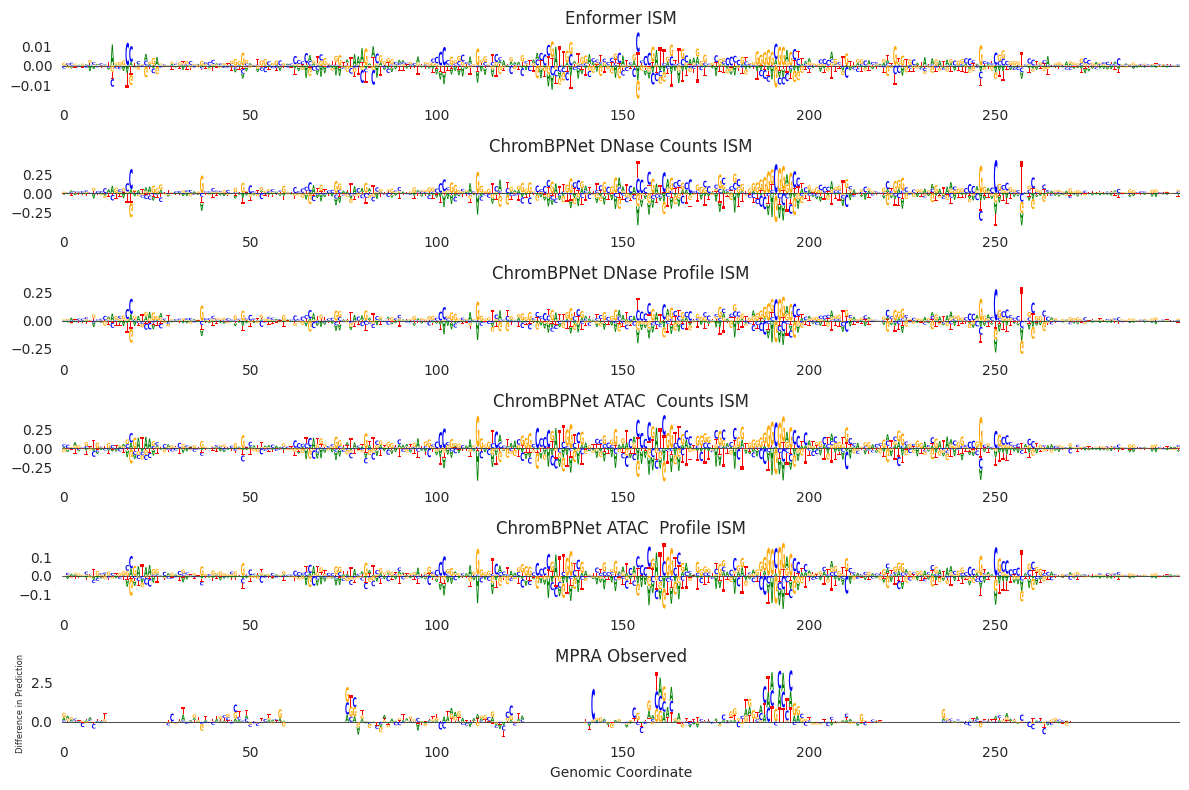

In [68]:
import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('white')
from tangermeme.plot import plot_logo

fig, axs = plt.subplots(nrows=6, ncols=1, figsize=(12, 8)) # Creates 3 vertically stacked subplots

plot_logo((enformer_attr)[0], ax=axs[0])
plot_logo((dnase_attr)[0], ax=axs[1])
plot_logo((profile_dnase_attr)[0], ax=axs[2])
plot_logo((atac_attr)[0], ax=axs[3])
plot_logo((profile_atac_attr)[0], ax=axs[4])
plot_logo((labels)[0], ax=axs[5])

axs[0].set_title("Enformer ISM")
axs[1].set_title("ChromBPNet DNase Counts ISM")
axs[2].set_title("ChromBPNet DNase Profile ISM")
axs[3].set_title("ChromBPNet ATAC  Counts ISM")
axs[4].set_title("ChromBPNet ATAC  Profile ISM")
axs[5].set_title("MPRA Observed")

axs[5].set_xlabel("Genomic Coordinate")
axs[5].set_ylabel("Difference in Prediction", fontsize=6)
# plt.title("Ref Allele")
# axs[0].set_ylim((0,max_v1))
# axs[1].set_ylim((0,max_v1))
plt.tight_layout()
title="ISM-HBG1-hypo.pdf"
plt.savefig("subfigs/"+title+".pdf", transparent=True, dpi=300)


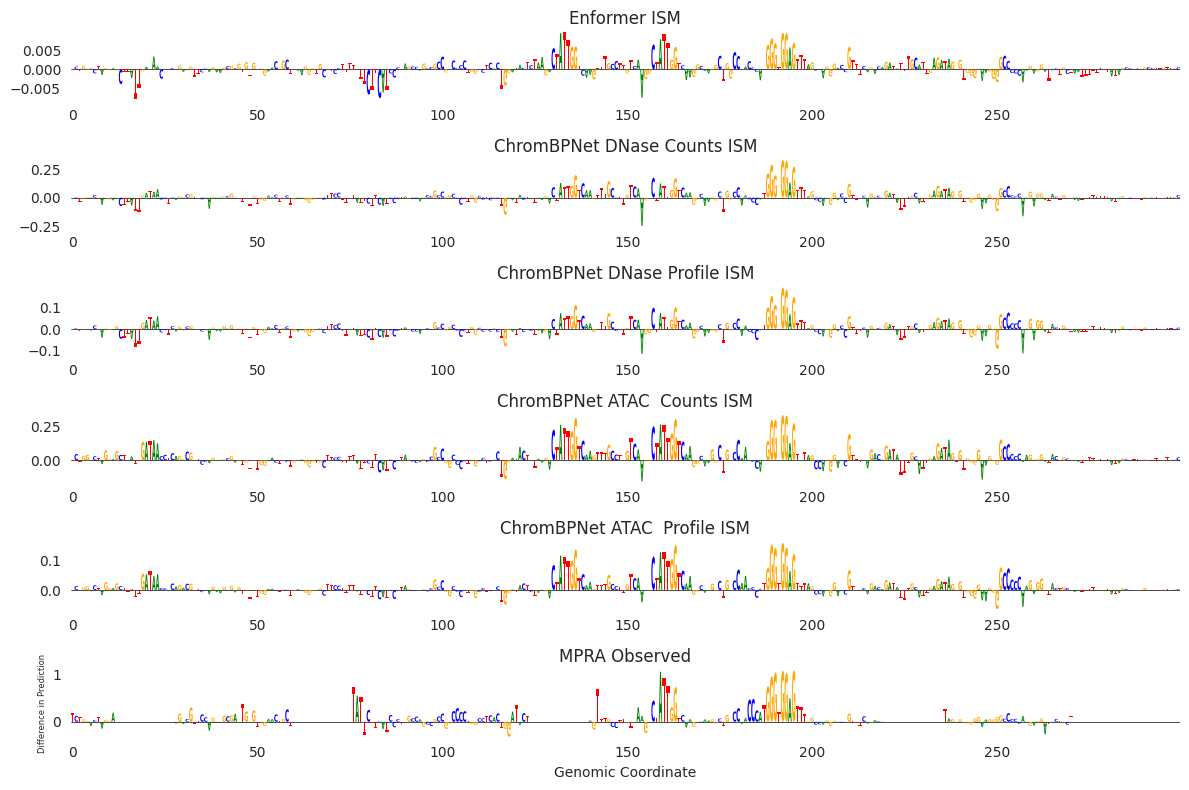

In [70]:
seq = genome[chrm][pos0-300//2:pos0+300//2].seq.upper()
counter=0
labels = np.zeros_like(enformer_attr)
key = {'A':0, 'C':1, 'G':2, 'T':3}

for idx in range(pos0-300//2,pos0+300//2):
    if datadf[(datadf["var.pos_hg19"]==idx+1) & (datadf["var.allele1"]==seq[counter])].shape[0] > 0:
        df = datadf[(datadf["var.pos_hg19"]==idx+1) & (datadf["var.allele1"]==seq[counter])]
        labels[0,key[seq[counter]], counter] = df["obs.label"].mean()*-1
        #print(counter, key[seq[counter]], labels[0,key[r["var.allele2"]], counter])
    elif datadf[(datadf["var.pos_hg19"]==idx+1) & (datadf["var.allele2"]==seq[counter])].shape[0] > 0:
        df = datadf[(datadf["var.pos_hg19"]==idx+1) & (datadf["var.allele2"]==seq[counter])]
        labels[0,key[seq[counter]], counter] = df["obs.label"].mean()*-2
    else:
        #print(idx)
        pass
    counter+=1


import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('white')
from tangermeme.plot import plot_logo

fig, axs = plt.subplots(nrows=6, ncols=1, figsize=(12, 8)) # Creates 3 vertically stacked subplots

plot_logo((enformer_attr * X[:, :, SEQLEN//2-150:SEQLEN//2+150])[0], ax=axs[0])
plot_logo((dnase_attr * X[:, :, SEQLEN//2-150:SEQLEN//2+150])[0], ax=axs[1])
plot_logo((profile_dnase_attr * X[:, :, SEQLEN//2-150:SEQLEN//2+150])[0], ax=axs[2])
plot_logo((atac_attr * X[:, :, SEQLEN//2-150:SEQLEN//2+150])[0], ax=axs[3])
plot_logo((profile_atac_attr * X[:, :, SEQLEN//2-150:SEQLEN//2+150])[0], ax=axs[4])
plot_logo((labels * X[:, :, SEQLEN//2-150:SEQLEN//2+150])[0], ax=axs[5])

axs[0].set_title("Enformer ISM")
axs[1].set_title("ChromBPNet DNase Counts ISM")
axs[2].set_title("ChromBPNet DNase Profile ISM")
axs[3].set_title("ChromBPNet ATAC  Counts ISM")
axs[4].set_title("ChromBPNet ATAC  Profile ISM")
axs[5].set_title("MPRA Observed")

axs[5].set_xlabel("Genomic Coordinate")
axs[5].set_ylabel("Difference in Prediction", fontsize=6)
# plt.title("Ref Allele")
# axs[0].set_ylim((0,max_v1))
# axs[1].set_ylim((0,max_v1))
plt.tight_layout()
title="ISM-HBG1-observed.pdf"
plt.savefig("subfigs/"+title+".pdf", transparent=True, dpi=300)